<a href="https://colab.research.google.com/github/jahnavi1thoom/story_generator_GPT/blob/main/story_generator_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: AI Story Generator using GPT
Dataset
Use:
roneneldan/TinyStories · Datasets at Hugging Face
Problem Statement
A publishing company wants an AI assistant capable of generating children's stories from short prompts.
Build a GPT-based Story Generation System.
Input:
Once upon a time
Output:
Once upon a time there was a little rabbit...
# Tasks:
Data Preparation
Tokenization
Embeddings
Positional Encoding
Masked Attention
GPT Decoder
Training
Generation
Evaluation
roneneldan/TinyStories · Datasets at Hugging Face
We’re on a journey to advance and democratize artificial intelligence through open source and open science.


In [ ]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [ ]:
print(ds)
print(ds['train'][0])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})
{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}


The `ds` object is a `DatasetDict`, which holds different subsets of the dataset (often 'train', 'validation', and 'test'). To access the actual data, you need to specify a split, like `ds['train']`. Then you can use slicing to view individual examples.

Let's display the first 5 examples from the 'train' split of the dataset:

In [ ]:
for i in range(5):
    print(f"--- Example {i+1} ---")
    print(ds['train'][i]['text'])
    print("\n")

--- Example 1 ---
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


--- Example 2 ---
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tre

# Task 1: Data Preparation

In [ ]:
train_texts = ds['train']['text'][:5000]
val_texts = ds['validation']['text'][:1000]

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))

print("\nSample Story:\n")
print(train_texts[0])

Training Samples: 5000
Validation Samples: 1000

Sample Story:

One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


In [ ]:
#Text Length Analysis
lengths = [len(text.split()) for text in train_texts]

print("Average Length:", sum(lengths)/len(lengths))
print("Maximum Length:", max(lengths))
print("Minimum Length:", min(lengths))

Average Length: 162.1618
Maximum Length: 837
Minimum Length: 48


# Task 2: Tokenization

In [ ]:
#load GPT Tokenizer
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

tokenizer.pad_token = tokenizer.eos_token

print("Vocabulary Size:", tokenizer.vocab_size)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Vocabulary Size: 50257


In [ ]:
#Tokenize Dataset
max_length = 128

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding="max_length",
    max_length=max_length
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding="max_length",
    max_length=max_length
)

print("Tokenized Samples:", len(train_encodings["input_ids"]))

Tokenized Samples: 5000


# Task 3: Embeddings

In [ ]:
#Word Embeddings
import torch
import torch.nn as nn

vocab_size = tokenizer.vocab_size
embedding_dim = 256

embedding_layer = nn.Embedding(
    vocab_size,
    embedding_dim
)

sample_ids = torch.tensor(
    train_encodings["input_ids"][0]
)

embedded = embedding_layer(sample_ids)

print("Embedding Shape:")
print(embedded.shape)

Embedding Shape:
torch.Size([128, 256])


# Task 4: Positional Encoding

In [ ]:
#Create Positional Encoding
import math

def positional_encoding(max_len, d_model):

    pe = torch.zeros(max_len, d_model)

    position = torch.arange(
        0,
        max_len,
        dtype=torch.float
    ).unsqueeze(1)

    div_term = torch.exp(
        torch.arange(
            0,
            d_model,
            2
        ).float()
        * (-math.log(10000.0) / d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    return pe

pos_encoding = positional_encoding(
    128,
    embedding_dim
)

print(pos_encoding.shape)

torch.Size([128, 256])


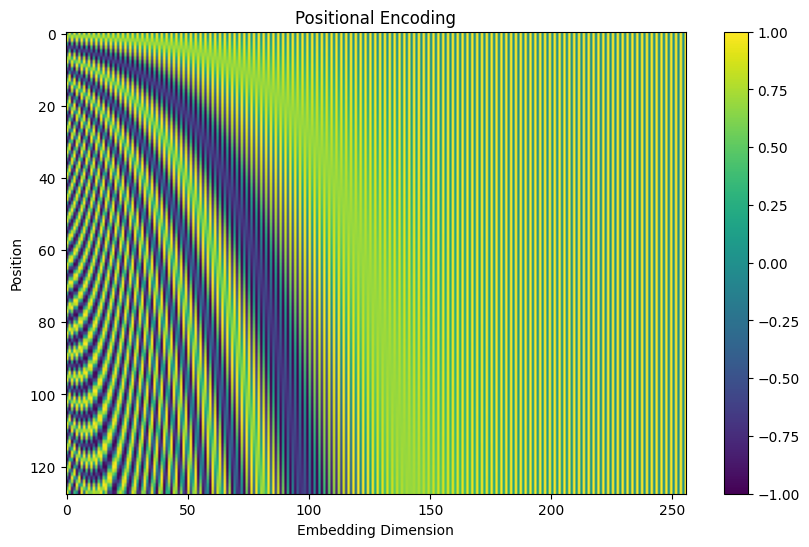

In [ ]:
#Visualize Positional Encoding
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(
    pos_encoding.numpy(),
    aspect='auto'
)

plt.colorbar()
plt.title("Positional Encoding")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.show()

# Task 5: Masked Attention

In [ ]:
#Generate Causal Mask
sequence_length = 20

mask = torch.triu(
    torch.ones(
        sequence_length,
        sequence_length
    ),
    diagonal=1
)

mask = mask.bool()

print(mask)

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False, Fa

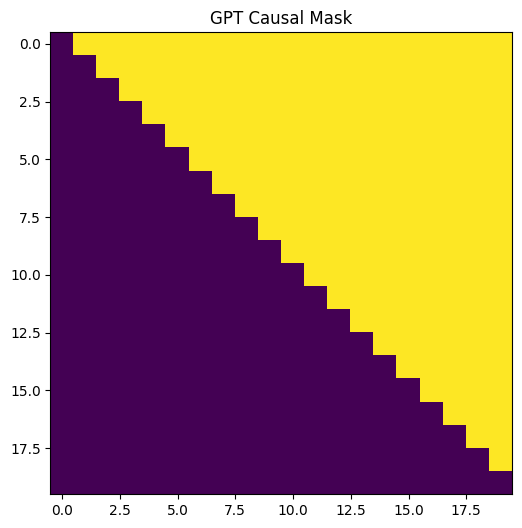

In [ ]:
#Visualize Mask
plt.figure(figsize=(6,6))

plt.imshow(mask)

plt.title("GPT Causal Mask")
plt.show()

# Task 6: GPT Decoder

In [ ]:
#Load GPT Mode
from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2")

print(model)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [ ]:
#Model Architecture Summary
print("Number of Parameters:")

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(total_params)

Number of Parameters:
124439808


# Task 7: Training

In [ ]:
#Create Dataset Class
from torch.utils.data import Dataset

class StoryDataset(Dataset):

    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(
            self.encodings["input_ids"]
        )

    def __getitem__(self, idx):

        return {
            "input_ids": torch.tensor(
                self.encodings["input_ids"][idx]
            ),
            "attention_mask": torch.tensor(
                self.encodings["attention_mask"][idx]
            ),
            "labels": torch.tensor(
                self.encodings["input_ids"][idx]
            )
        }

In [ ]:
#Create Train Dataset
train_dataset = StoryDataset(
    train_encodings
)

val_dataset = StoryDataset(
    val_encodings
)

print(len(train_dataset))

5000


In [ ]:
#Training Arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./story_gpt",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    save_steps=500,
    logging_steps=100
)

In [ ]:
#Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,2.246512
200,2.087399
300,2.019876
400,2.004330
500,2.009618
600,1.961510
700,1.969190
800,1.946115
900,1.921062
1000,1.925999


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=1.984850274658203, metrics={'train_runtime': 232.9598, 'train_samples_per_second': 21.463, 'train_steps_per_second': 5.366, 'total_flos': 326615040000000.0, 'train_loss': 1.984850274658203, 'epoch': 1.0})

# Task 8: Story Generation

In [ ]:
import torch

#Generate Story
prompt = "Once upon a time"

inputs = tokenizer.encode(
    prompt,
    return_tensors="pt"
)

# Move input tensor to GPU if available
if torch.cuda.is_available():
    inputs = inputs.to('cuda')
    model.to('cuda') # Ensure model is also on CUDA

outputs = model.generate(
    inputs,
    max_length=150,
    do_sample=True,
    temperature=0.8,
    top_k=50,
    top_p=0.95
)

story = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(story)

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Once upon a time, there was a girl named Lucy. Lucy loved playing with her dolls. One day, Lucy saw a toy and it was very cute. Lucy was so excited. She asked her mom, "Mommy, can you make me a toy?"

Mommy smiled and said, "Sure, Lucy. What kind of toys can you make?"

Lucy started to draw a picture of a doll and her mom asked, "Will you make a doll that will be happy?"

Lucy's mom said, "Of course I will! I'm sure you can make me a toy!"

Lucy was so happy that she wanted to play with her dolls. They were all playing together and Lucy was


In [ ]:
import torch

#Generate Multiple Stories
prompts = [
    "Once upon a time",
    "A little rabbit",
    "There was a magical forest"
]

for p in prompts:

    inputs = tokenizer.encode(
        p,
        return_tensors="pt"
    )

    # Move input tensor to GPU if available
    if torch.cuda.is_available():
        inputs = inputs.to('cuda')
        model.to('cuda') # Ensure model is also on CUDA

    outputs = model.generate(
        inputs,
        max_length=120
    )

    print("\nPrompt:", p)

    print(
        tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )
    )

[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Prompt: Once upon a time
Once upon a time, there was a little girl named Lily. She loved to play with her toys and make them look nice. One day, she saw a big, green tree with a big, green tree. She wanted to play with it, so she asked her mom if she could play with it.

Her mom said yes, and Lily was so excited! She ran to the tree and started to play with it. She was so happy and happy to have a big green tree with a big green tree.

When Lily was done playing, she went to her mom and said


[transformers] The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



Prompt: A little rabbit
A little rabbit was very curious. She wanted to explore the world around her. She wanted to see what was around her.

Her mom said, "Let's go to the park and see what's around the corner."

So, they went to the park. They saw a big tree and a big tree. They saw a big tree with a big tree. The tree was big and tall.

The little rabbit saw a big tree. She wanted to climb it. She climbed up the tree and climbed up the tree.

The little rabbit saw a big tree.

Prompt: There was a magical forest
There was a magical forest. It was so big and beautiful. Every day, the forest would glow with the sun.

One day, a little girl named Lily went to the forest to play. She saw a big tree with a big trunk. She wanted to climb it, so she climbed up to the trunk.

But then, a big, scary monster came. Lily was scared. She ran away from the monster and hid behind a bush.

The monster was very scary. He was very big and scary. Lily was scared. She ran away and hid behind a bush


# Task 9: Evaluation

In [ ]:
#Evaluate Model
results = trainer.evaluate(
    eval_dataset=val_dataset
)

print(results)

Training Loss,Validation Loss,Step
1.894662,1.731303,1250


{'eval_loss': 1.7313034534454346}


In [ ]:
#Calculate Perplexity
import math

eval_loss = results["eval_loss"]

perplexity = math.exp(eval_loss)

print("Perplexity:", perplexity)

Perplexity: 5.648011031992154


In [ ]:
#Save Model
model.save_pretrained("story_generator_model")

tokenizer.save_pretrained(
    "story_generator_model"
)

print("Model Saved Successfully")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved Successfully
